# 🔍 Detecção de Anomalias em Transações Financeiras
## Desafio Intermediário | Python + Google Colab

**Objetivo:** Identificar padrões para diferenciar transações normais de fraudulentas usando técnicas de ML, balanceamento e explicabilidade.

---
**Estrutura do Notebook:**
- **Parte 1** — Coleta e Análise Exploratória de Dados (EDA)  
- **Parte 2** — Feature Engineering e Técnicas de Balanceamento  
- **Parte 3** — Modelos Avançados, Ajuste de Hiperparâmetros e Explicabilidade (SHAP)


In [32]:
# Instalações necessárias (execute apenas uma vez)
!pip install shap imbalanced-learn -q

## Parte 1 — Coleta e Análise Exploratória de Dados

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    recall_score, precision_score, f1_score
)
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
import warnings
warnings.filterwarnings('ignore')

# Configuração visual
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})
sns.set_style('whitegrid')

print('✅ Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


In [47]:
# ── 1.1 Carregamento do Dataset ──────────────────────────────────────────────
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
print(f"Colunas: {list(df.columns)}")
print(f"\nValores nulos:\n{df.isnull().sum().sum()} (total)")
df.head()

Shape: (284807, 31)
Colunas: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Valores nulos:
0 (total)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [35]:
# ── 1.2 Estatísticas Descritivas ─────────────────────────────────────────────
df[['Time', 'Amount', 'Class']].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


### 1.3 Problema de Classificação Desbalanceada

In [36]:
# Proporção das classes
print("=== Contagem por Classe ===")
print(df["Class"].value_counts())
print()
print("=== Proporção ===")
print(df["Class"].value_counts(normalize=True).rename("proportion"))

=== Contagem por Classe ===
Class
0    284315
1       492
Name: count, dtype: int64

=== Proporção ===
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


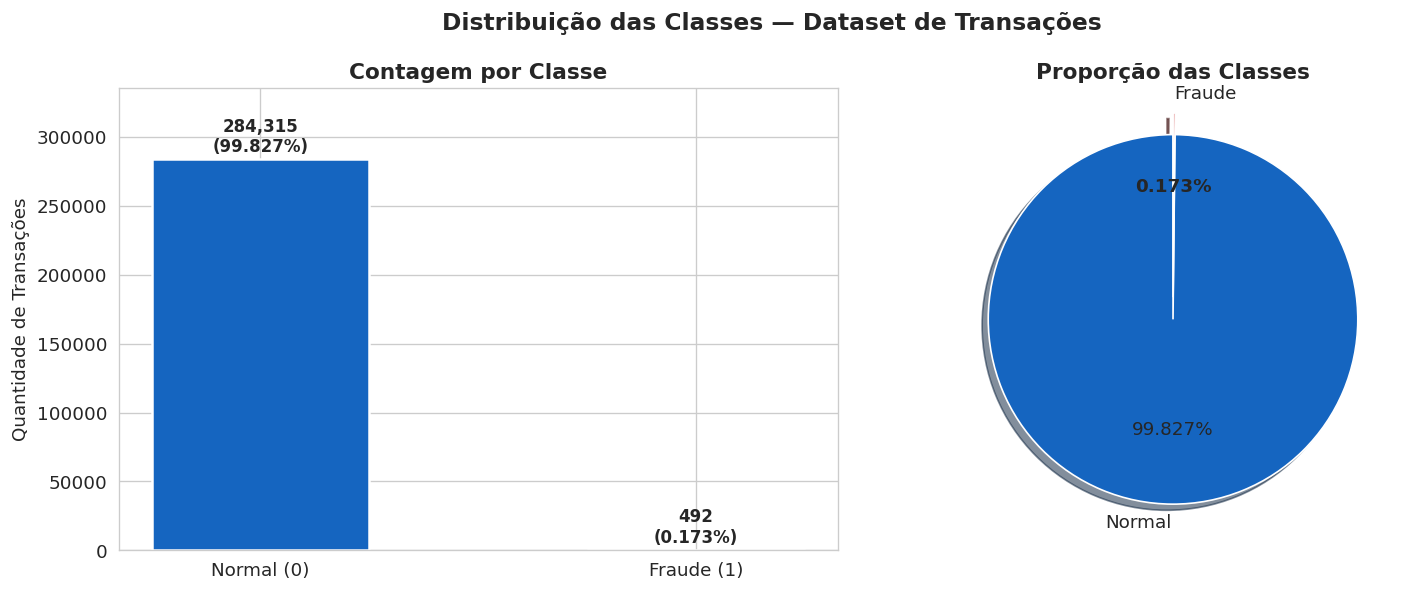

⚠️  Desbalanceamento extremo: apenas 0.17% de fraudes!


In [37]:
# ── Gráfico: Distribuição das Classes ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Distribuição das Classes — Dataset de Transações", fontsize=14, fontweight='bold')

class_counts = df["Class"].value_counts()
labels = ["Normal (0)", "Fraude (1)"]
colors  = ["#1565C0", "#C62828"]

# Barras
bars = axes[0].bar(labels, class_counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_ylabel("Quantidade de Transações")
axes[0].set_title("Contagem por Classe")
for bar, cnt in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2000,
                 f"{cnt:,}\n({cnt/len(df)*100:.3f}%)",
                 ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].set_ylim(0, class_counts.max() * 1.18)

# Pizza
wedges, texts, autotexts = axes[1].pie(
    class_counts.values, labels=["Normal", "Fraude"],
    colors=colors, autopct="%1.3f%%", startangle=90,
    explode=(0, 0.12), shadow=True,
    textprops={'fontsize': 11}
)
autotexts[1].set_fontweight('bold')
axes[1].set_title("Proporção das Classes")

plt.tight_layout()
plt.savefig("01_distribuicao_classes.png", bbox_inches='tight')
plt.show()
print("⚠️  Desbalanceamento extremo: apenas 0.17% de fraudes!")

### 1.4 Análise Exploratória de Features

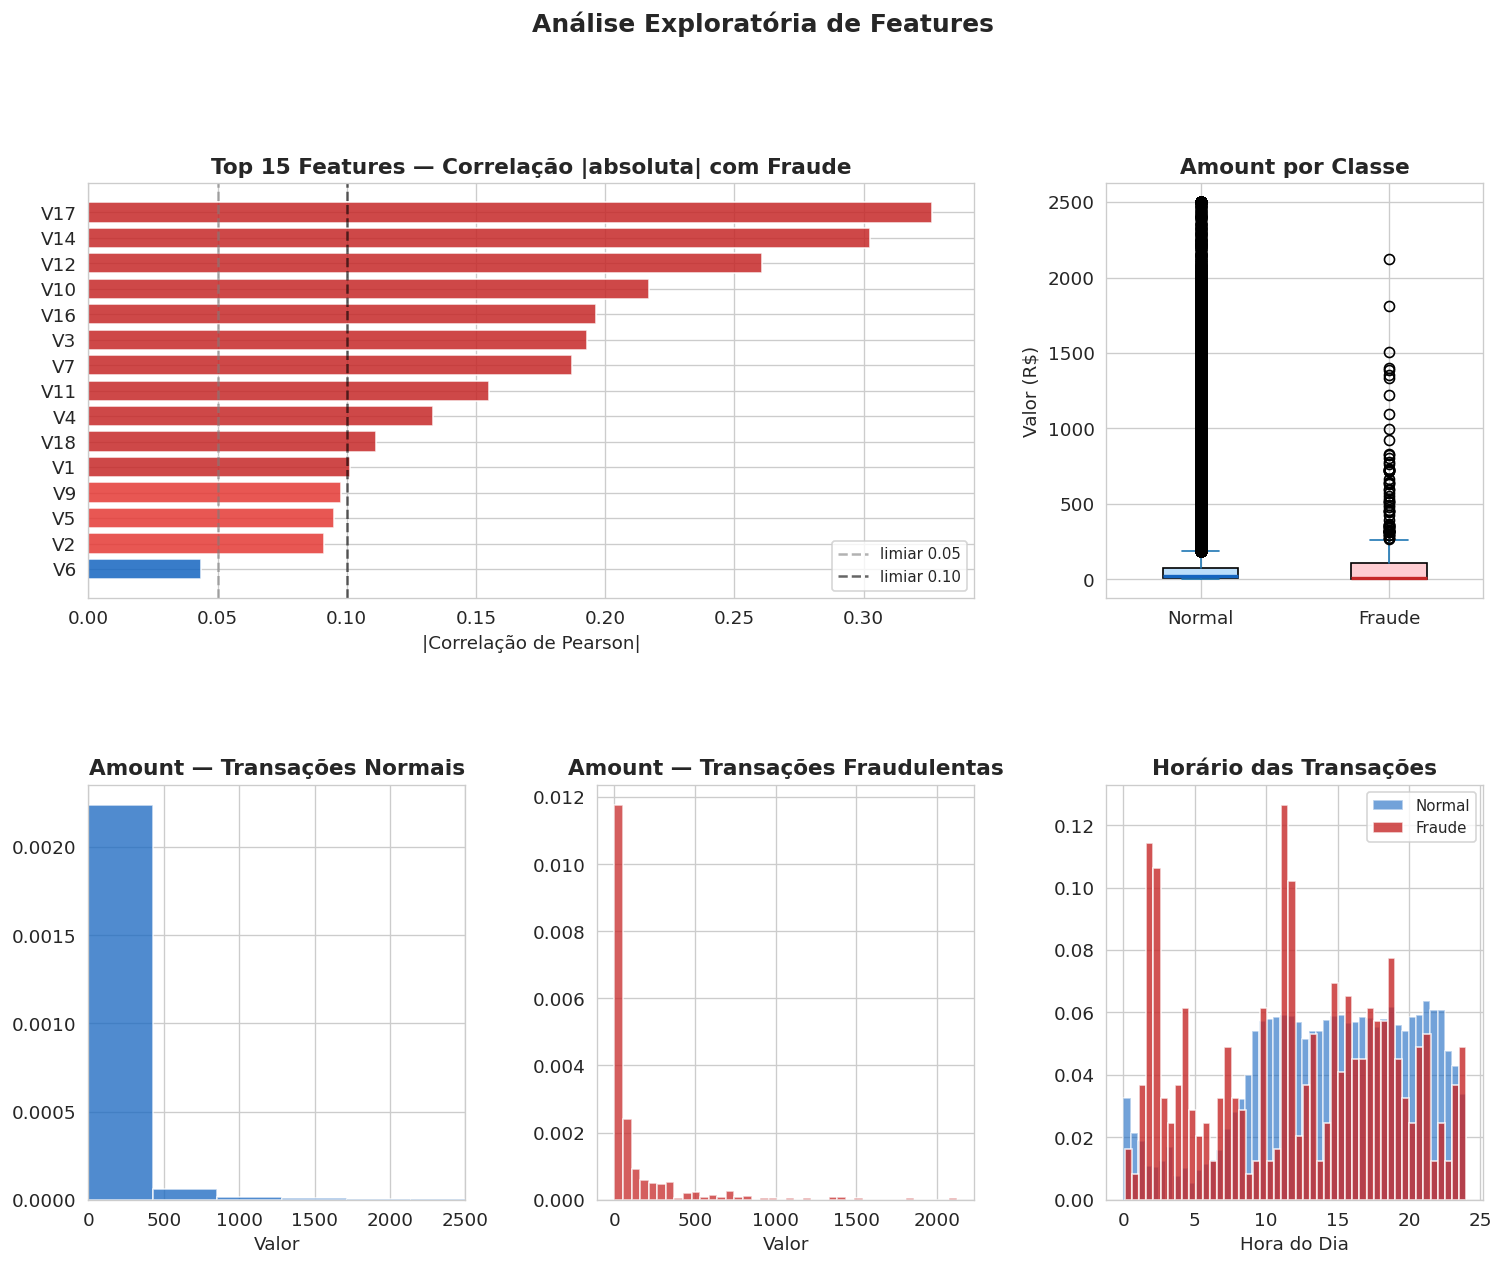

In [38]:
# ── Gráfico: Análise de Features ─────────────────────────────────────────────
fig = plt.figure(figsize=(15, 11))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[1, 2])

fig.suptitle("Análise Exploratória de Features", fontsize=15, fontweight='bold', y=1.01)

# 1. Correlação com a classe alvo
corr = df.corr()["Class"].drop("Class").abs().sort_values(ascending=True)
top15 = corr.tail(15)
bar_colors = ["#C62828" if v > 0.1 else "#E53935" if v > 0.05 else "#1565C0" for v in top15.values]
ax1.barh(top15.index, top15.values, color=bar_colors, alpha=0.85)
ax1.set_title("Top 15 Features — Correlação |absoluta| com Fraude")
ax1.set_xlabel("|Correlação de Pearson|")
ax1.axvline(x=0.05, color='gray', linestyle='--', alpha=0.6, label='limiar 0.05')
ax1.axvline(x=0.10, color='black', linestyle='--', alpha=0.6, label='limiar 0.10')
ax1.legend(fontsize=9)

# 2. Amount por classe (boxplot)
df[df['Class']==0]['Amount'].clip(upper=2500).plot.box(ax=ax2, positions=[0], widths=0.4,
    patch_artist=True, boxprops=dict(facecolor='#BBDEFB'),
    medianprops=dict(color='#1565C0', linewidth=2))
df[df['Class']==1]['Amount'].plot.box(ax=ax2, positions=[1], widths=0.4,
    patch_artist=True, boxprops=dict(facecolor='#FFCDD2'),
    medianprops=dict(color='#C62828', linewidth=2))
ax2.set_xticklabels(['Normal', 'Fraude'])
ax2.set_title("Amount por Classe")
ax2.set_ylabel("Valor (R$)")

# 3. Distribuição do Amount — Normal (zoom)
ax3.hist(df[df["Class"]==0]["Amount"], bins=60, color="#1565C0", alpha=0.75, density=True)
ax3.set_xlim([0, 2500])
ax3.set_title("Amount — Transações Normais")
ax3.set_xlabel("Valor")

# 4. Distribuição do Amount — Fraude
ax4.hist(df[df["Class"]==1]["Amount"], bins=40, color="#C62828", alpha=0.75, density=True)
ax4.set_title("Amount — Transações Fraudulentas")
ax4.set_xlabel("Valor")

# 5. Distribuição temporal
hours = (df["Time"] / 3600) % 24
ax5.hist(hours[df["Class"]==0], bins=48, color="#1565C0", alpha=0.6, label='Normal', density=True)
ax5.hist(hours[df["Class"]==1], bins=48, color="#C62828", alpha=0.8, label='Fraude', density=True)
ax5.set_title("Horário das Transações")
ax5.set_xlabel("Hora do Dia")
ax5.legend(fontsize=9)

plt.savefig("02_analise_features.png", bbox_inches='tight')
plt.show()

---
## Parte 2 — Feature Engineering e Técnicas de Balanceamento

### 2.1 Feature Engineering

In [39]:
# ── Feature Engineering ──────────────────────────────────────────────────────
df_eng = df.copy()

# Hora do dia (codificação cíclica para preservar continuidade)
df_eng["hour"]     = (df_eng["Time"] / 3600) % 24
df_eng["hour_sin"] = np.sin(2 * np.pi * df_eng["hour"] / 24)
df_eng["hour_cos"] = np.cos(2 * np.pi * df_eng["hour"] / 24)

# Indicador de madrugada (alta incidência de fraudes entre 22h e 6h)
df_eng["is_night"] = ((df_eng["hour"] >= 22) | (df_eng["hour"] <= 6)).astype(int)

# Log do valor — reduz skewness do Amount
df_eng["log_amount"] = np.log1p(df_eng["Amount"])

# Remover colunas brutas substituídas
df_eng.drop(columns=["Time", "Amount", "hour"], inplace=True)

print(f"Shape após Feature Engineering: {df_eng.shape}")
print(f"Novas features: hour_sin, hour_cos, is_night, log_amount")
df_eng[["hour_sin", "hour_cos", "is_night", "log_amount", "Class"]].describe()

Shape após Feature Engineering: (284807, 33)
Novas features: hour_sin, hour_cos, is_night, log_amount


,hour_sin,hour_cos,is_night,log_amount,Class
count,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000
mean,-0.266787,-0.140733,0.176660,3.152188,0.001727
std,0.628132,0.717268,0.381381,1.656648,0.041527
min,-1.000000,-1.000000,0.000000,0.000000,0.000000
25%,-0.841236,-0.837083,0.000000,1.887070,0.000000
50%,-0.435624,-0.311920,0.000000,3.135494,0.000000
75%,0.247422,0.597800,0.000000,4.358822,0.000000
max,1.000000,1.000000,1.000000,10.153941,1.000000


### 2.2 Split Treino/Teste e Normalização

In [40]:
# ── Preparação para Modelagem ────────────────────────────────────────────────
X = df_eng.drop(columns=["Class"])
y = df_eng["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino : {X_train.shape}  |  Fraudes: {y_train.sum():,} ({y_train.mean()*100:.3f}%)")
print(f"Teste  : {X_test.shape}   |  Fraudes: {y_test.sum():,}  ({y_test.mean()*100:.3f}%)")

# Normalização (StandardScaler fit apenas no treino)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("\n✅ Split estratificado + normalização concluídos.")

Treino : (227845, 32)  |  Fraudes: 394 (0.173%)
Teste  : (56962, 32)   |  Fraudes: 98  (0.172%)

✅ Split estratificado + normalização concluídos.


### 2.3 Baseline — Logistic Regression (sem balanceamento)

In [41]:
# ── Baseline: LR sem balanceamento ───────────────────────────────────────────
lr_base = LogisticRegression(max_iter=2000, solver='saga', random_state=42)
lr_base.fit(X_train_sc, y_train)
y_pred_base = lr_base.predict(X_test_sc)
y_prob_base = lr_base.predict_proba(X_test_sc)[:, 1]

print("=== BASELINE — Logistic Regression (sem balanceamento) ===")
print(classification_report(y_test, y_pred_base, target_names=["Normal", "Fraude"]))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_base):.4f}")
print()
print("💡 Accuracy alta engana! Recall de fraude é o que importa.")

=== BASELINE — Logistic Regression (sem balanceamento) ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.83      0.66      0.74        98

    accuracy                           1.00     56962
   macro avg       0.92      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC : 0.9561

💡 Accuracy alta engana! Recall de fraude é o que importa.


### 2.4 Undersampling — RandomUnderSampler

In [42]:
# ── Undersampling ────────────────────────────────────────────────────────────
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train_sc, y_train)

print(f"Após Undersampling — Normal: {(y_under==0).sum():,} | Fraude: {(y_under==1).sum():,}")

lr_under = LogisticRegression(max_iter=2000, random_state=42)
lr_under.fit(X_under, y_under)
y_pred_under = lr_under.predict(X_test_sc)
y_prob_under = lr_under.predict_proba(X_test_sc)[:, 1]

print("\n=== UNDERSAMPLING — Logistic Regression ===")
print(classification_report(y_test, y_pred_under, target_names=["Normal", "Fraude"]))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_under):.4f}")

Após Undersampling — Normal: 394 | Fraude: 394

=== UNDERSAMPLING — Logistic Regression ===
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98     56864
      Fraude       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962

ROC-AUC : 0.9762


### 2.5 Oversampling — SMOTE (Synthetic Minority Over-sampling Technique)

In [43]:
# ── SMOTE ─────────────────────────────────────────────────────────────────────
smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_train_sc, y_train)

print(f"Após SMOTE — Normal: {(y_smote==0).sum():,} | Fraude: {(y_smote==1).sum():,}")

lr_smote = LogisticRegression(max_iter=2000, random_state=42)
lr_smote.fit(X_smote, y_smote)
y_pred_smote = lr_smote.predict(X_test_sc)
y_prob_smote = lr_smote.predict_proba(X_test_sc)[:, 1]

print("\n=== SMOTE — Logistic Regression ===")
print(classification_report(y_test, y_pred_smote, target_names=["Normal", "Fraude"]))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_smote):.4f}")

Após SMOTE — Normal: 227,451 | Fraude: 227,451

=== SMOTE — Logistic Regression ===
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
      Fraude       0.06      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC : 0.9719


### 2.6 Comparação Visual das Técnicas de Balanceamento

=== TABELA COMPARATIVA ===
                         Recall  Precision  F1-Score  ROC-AUC
Baseline\n(sem balanc.)  0.6633     0.8333    0.7386   0.9561
Undersampling            0.9184     0.0375    0.0720   0.9762
SMOTE                    0.9184     0.0551    0.1040   0.9719


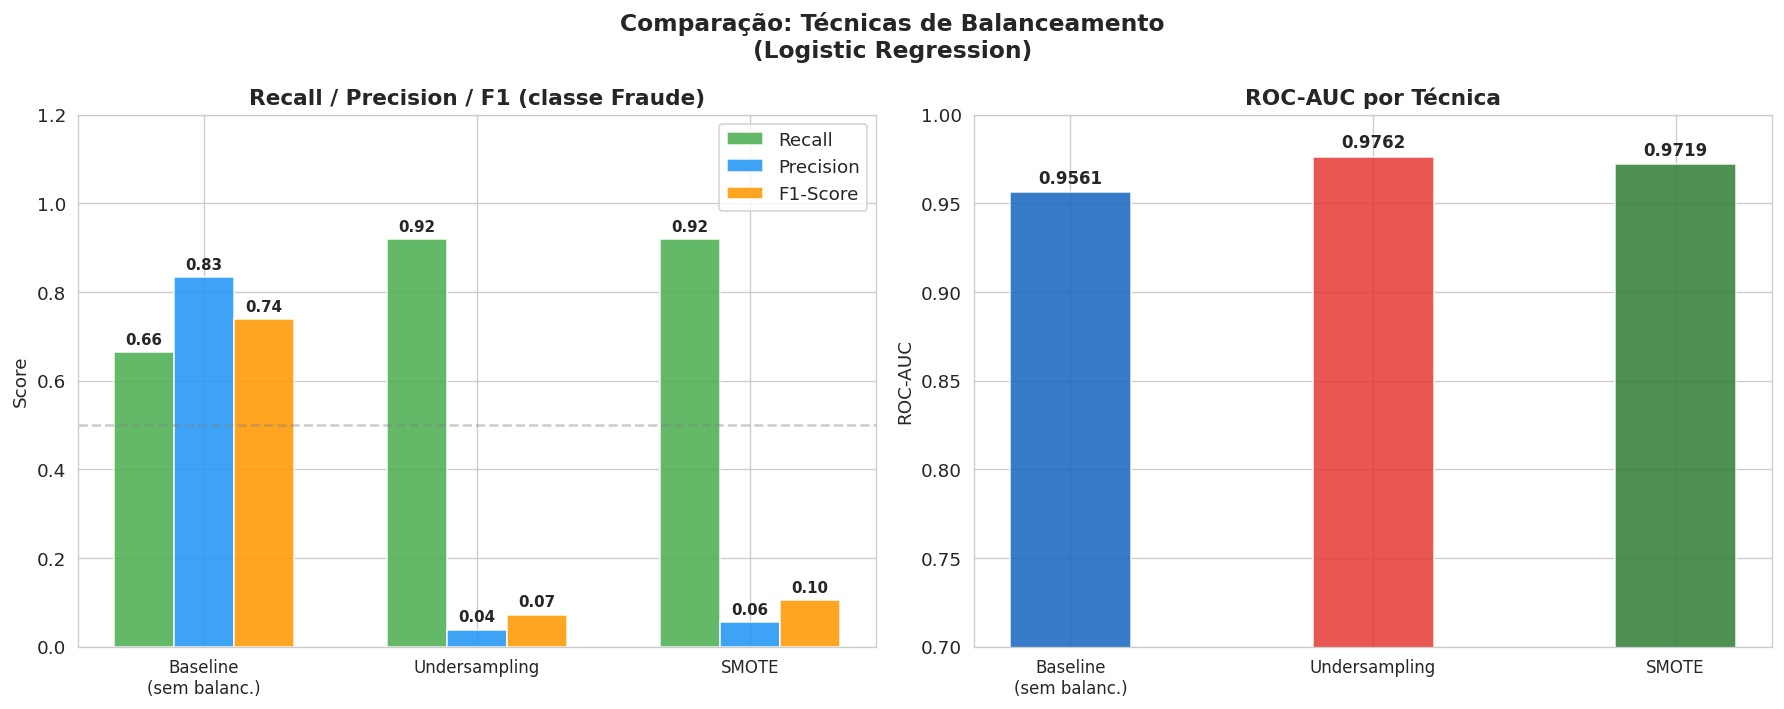

In [44]:
# ── Comparação de Métricas ────────────────────────────────────────────────────
resultados = {}
for nome, y_p, y_pr in [
    ("Baseline\n(sem balanc.)", y_pred_base, y_prob_base),
    ("Undersampling",            y_pred_under, y_prob_under),
    ("SMOTE",                    y_pred_smote, y_prob_smote),
]:
    resultados[nome] = {
        "Recall":    recall_score(y_test, y_p),
        "Precision": precision_score(y_test, y_p, zero_division=0),
        "F1-Score":  f1_score(y_test, y_p),
        "ROC-AUC":   roc_auc_score(y_test, y_pr),
    }

res_df = pd.DataFrame(resultados).T
print("=== TABELA COMPARATIVA ===")
print(res_df.round(4).to_string())

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Comparação: Técnicas de Balanceamento\n(Logistic Regression)", fontsize=14, fontweight='bold')

x = np.arange(len(res_df))
w = 0.22
metricas = ["Recall", "Precision", "F1-Score"]
cores    = ["#4CAF50", "#2196F3", "#FF9800"]

for i, (m, c) in enumerate(zip(metricas, cores)):
    bars = axes[0].bar(x + i*w, res_df[m], w, label=m, color=c, alpha=0.87)
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.012,
                     f"{bar.get_height():.2f}",
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[0].set_xticks(x + w)
axes[0].set_xticklabels(res_df.index, fontsize=10)
axes[0].set_ylim(0, 1.2)
axes[0].set_ylabel("Score")
axes[0].set_title("Recall / Precision / F1 (classe Fraude)")
axes[0].legend()
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.4)

# ROC-AUC comparativo
cores_roc = ["#1565C0", "#E53935", "#2E7D32"]
bars2 = axes[1].bar(res_df.index, res_df["ROC-AUC"], color=cores_roc, alpha=0.85, width=0.4)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f"{bar.get_height():.4f}",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylim(0.7, 1.0)
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("ROC-AUC por Técnica")
axes[1].tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.savefig("03_comparacao_balanceamento.png", bbox_inches='tight')
plt.show()

---
## Parte 3 — Modelos Avançados, Hiperparâmetros e Explicabilidade (SHAP)

### 3.1 Random Forest com Pipeline + SMOTE

In [45]:
# ── Pipeline: SMOTE + Random Forest ─────────────────────────────────────────
pipeline_rf = ImbPipeline([
    ("scaler",     StandardScaler()),
    ("smote",      SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        n_estimators   = 100,
        max_depth       = 10,
        min_samples_split = 10,
        class_weight    = "balanced",
        random_state    = 42,
        n_jobs          = -1
    ))
])

pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
y_prob_rf  = pipeline_rf.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST — Pipeline com SMOTE ===")
print(classification_report(y_test, y_pred_rf, target_names=["Normal", "Fraude"]))
print(f"ROC-AUC          : {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_prob_rf):.4f}")

=== RANDOM FOREST — Pipeline com SMOTE ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.43      0.87      0.58        98

    accuracy                           1.00     56962
   macro avg       0.72      0.93      0.79     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC          : 0.9835
Average Precision: 0.8058


### 3.2 Ajuste Simplificado de Hiperparâmetros — Random Forest

In [58]:
# ── 3.2 Ajuste Simplificado — rápido e estável para Google Colab ──

# Estratégia:
# 1. Aplicar scaler e SMOTE apenas uma vez
# 2. Treinar Random Forest com hiperparâmetros já ajustados
# 3. Evitar RandomizedSearchCV / GridSearchCV para reduzir tempo

scaler_tune = StandardScaler()
X_train_sc2 = scaler_tune.fit_transform(X_train)
X_test_sc2  = scaler_tune.transform(X_test)

smote_tune = SMOTE(random_state=42)
X_bal, y_bal = smote_tune.fit_resample(X_train_sc2, y_train)

print(f"Treino balanceado: Normal={(y_bal==0).sum():,} | Fraude={(y_bal==1).sum():,}")

best_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=10,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_bal, y_bal)

# Calcular as probabilidades para o modelo best_rf para uso nas curvas de avaliação
y_prob_best = best_rf.predict_proba(X_test_sc2)[:, 1]
y_pred_best = best_rf.predict(X_test_sc2)

print('✅ Modelo treinado com sucesso!')
print('Parâmetros utilizados:')
print(best_rf.get_params())

Treino balanceado: Normal=227,451 | Fraude=227,451
✅ Modelo treinado com sucesso!
Parâmetros utilizados:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 12, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


### 3.3 Curvas de Avaliação — ROC e Precision-Recall

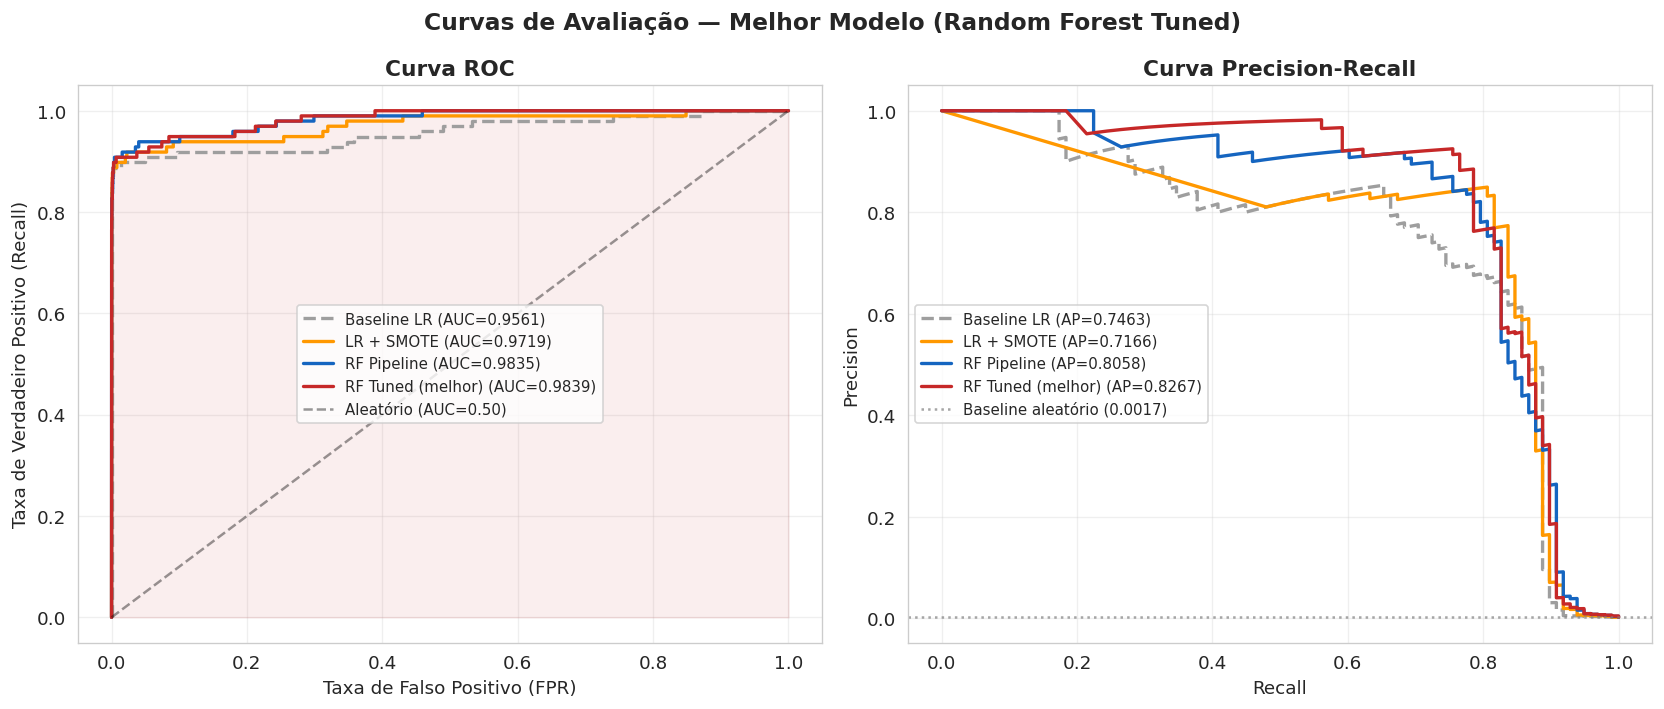

In [57]:
# ── Curvas ROC e Precision-Recall ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Curvas de Avaliação — Melhor Modelo (Random Forest Tuned)", fontsize=14, fontweight='bold')

# ─ Curva ROC
modelos_roc = [
    ("Baseline LR",       y_prob_base,  "#9E9E9E", "--"),
    ("LR + SMOTE",        y_prob_smote, "#FF9800", "-"),
    ("RF Pipeline",       y_prob_rf,    "#1565C0", "-"),
    ("RF Tuned (melhor)", y_prob_best,  "#C62828", "-"),
]
for nome, prob, cor, ls in modelos_roc:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, color=cor, lw=2, linestyle=ls, label=f"{nome} (AUC={auc:.4f})")
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Aleatório (AUC=0.50)')
axes[0].fill_between(*roc_curve(y_test, y_prob_best)[:2], alpha=0.08, color='#C62828')
axes[0].set_title("Curva ROC")
axes[0].set_xlabel("Taxa de Falso Positivo (FPR)")
axes[0].set_ylabel("Taxa de Verdadeiro Positivo (Recall)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ─ Curva Precision-Recall
for nome, prob, cor, ls in modelos_roc:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[1].plot(rec, prec, color=cor, lw=2, linestyle=ls, label=f"{nome} (AP={ap:.4f})")
axes[1].axhline(y=y_test.mean(), color='gray', linestyle=':', alpha=0.7,
                label=f"Baseline aleatório ({y_test.mean():.4f})")
axes[1].set_title("Curva Precision-Recall")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("04_curvas_avaliacao.png", bbox_inches='tight')
plt.show()

### 3.4 Matrizes de Confusão

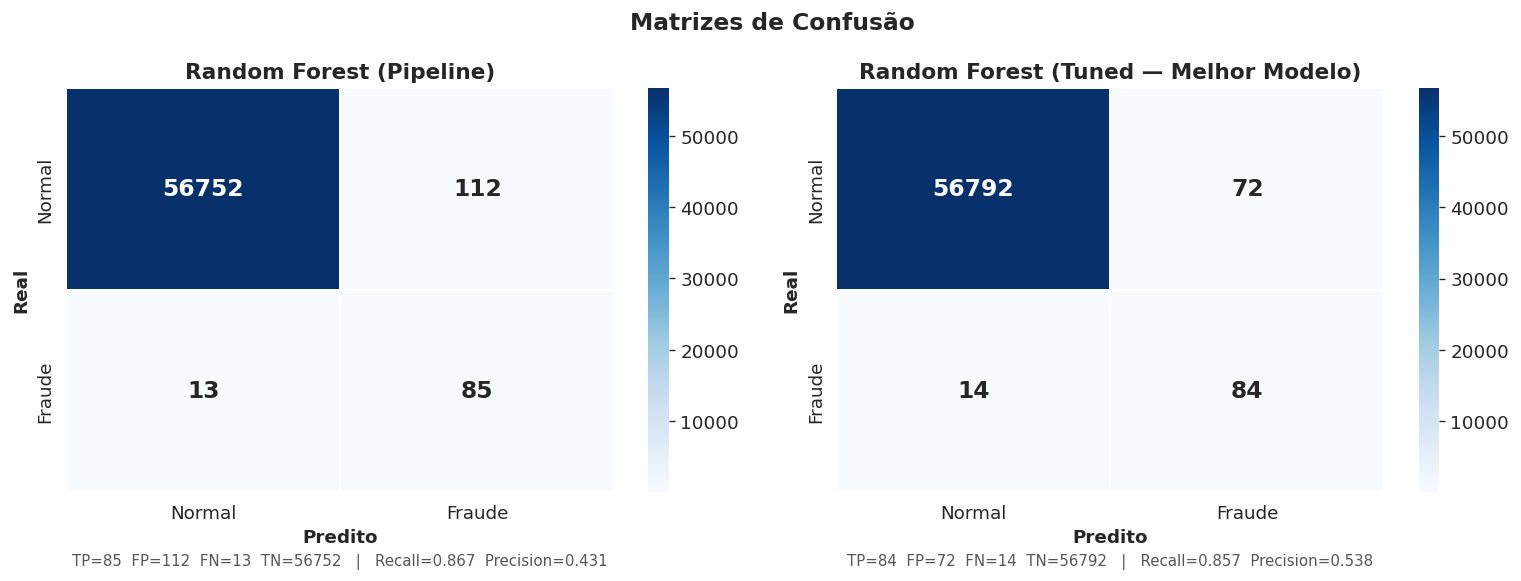

In [56]:
# ── Matrizes de Confusão ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Matrizes de Confusão", fontsize=14, fontweight='bold')

for ax, (y_p, titulo) in zip(axes, [
    (y_pred_rf,   "Random Forest (Pipeline)"),
    (y_pred_best, "Random Forest (Tuned — Melhor Modelo)"),
]):
    cm = confusion_matrix(y_test, y_p)
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', linewidths=1, linecolor='white',
                xticklabels=["Normal", "Fraude"],
                yticklabels=["Normal", "Fraude"],
                annot_kws={"size": 14, "weight": "bold"})

    ax.set_title(titulo)
    ax.set_xlabel("Predito", fontweight='bold')
    ax.set_ylabel("Real", fontweight='bold')
    ax.text(0.5, -0.18,
            f"TP={tp}  FP={fp}  FN={fn}  TN={tn}   |   "
            f"Recall={tp/(tp+fn):.3f}  Precision={tp/(tp+fp):.3f}",
            transform=ax.transAxes, ha='center', fontsize=9, color='#555')

plt.tight_layout()
plt.savefig("05_matrizes_confusao.png", bbox_inches='tight')
plt.show()

### 3.5 Explicabilidade — SHAP (SHapley Additive exPlanations)

In [59]:
# ── SHAP: Configuração ───────────────────────────────────────────────────────
# Extrair componentes do pipeline
rf_model = best_rf
# scaler_tune já foi criado na etapa anterior
X_test_sc_shap = scaler_tune.transform(X_test)

# Amostra para eficiência (SHAP em árvores é rápido, mas usamos 1000 amostras)
sample_size   = min(1000, len(X_test))
np.random.seed(42)
idx_sample    = np.random.choice(len(X_test), sample_size, replace=False)
X_shap_sample = pd.DataFrame(X_test_sc_shap[idx_sample], columns=X_test.columns)

# Calcular SHAP values
explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap_sample)

# Para classificação binária, pegar classe 1 (fraude)
shap_fraud = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f"✅ SHAP calculado para {sample_size} amostras.")
print(f"   Shape: {shap_fraud.shape}")

✅ SHAP calculado para 1000 amostras.
   Shape: (1000, 32, 2)


<Figure size 1200x840 with 0 Axes>

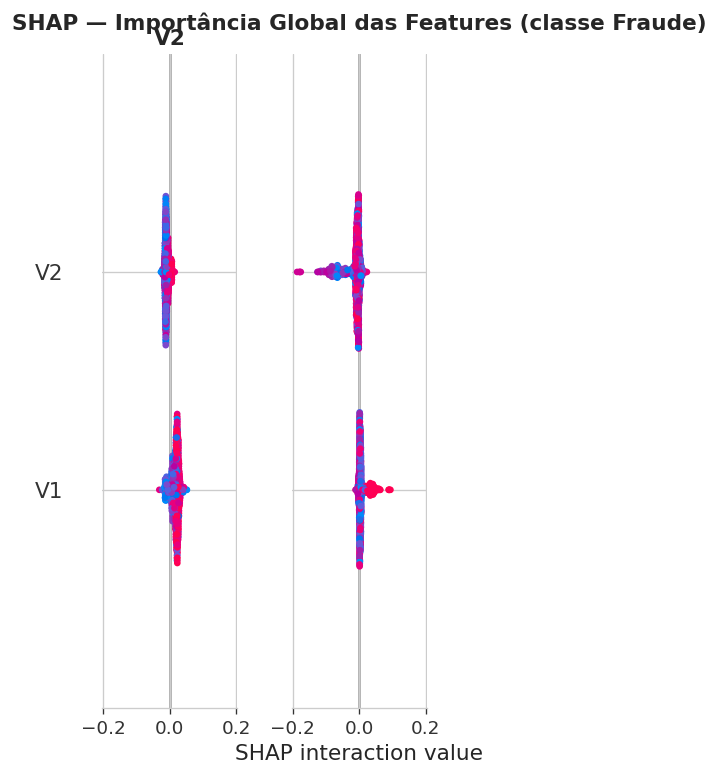

In [54]:
# ── SHAP: Summary Bar Plot ───────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_fraud, X_shap_sample, plot_type="bar", show=False,
                  color="#C62828")
plt.title("SHAP — Importância Global das Features (classe Fraude)", pad=15)
plt.tight_layout()
plt.savefig("06_shap_importancia_bar.png", bbox_inches='tight')
plt.show()

<Figure size 1200x960 with 0 Axes>

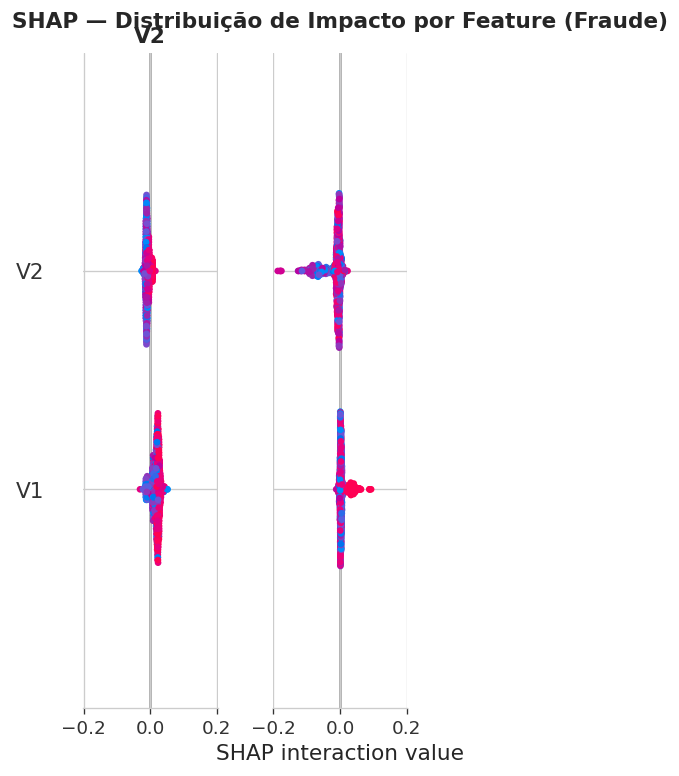

Como ler: azul = valor baixo da feature | vermelho = valor alto
Eixo X (SHAP): positivo → aumenta risco de fraude | negativo → reduz risco


In [52]:
# ── SHAP: Beeswarm (Summary Plot) ────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_fraud, X_shap_sample, show=False)
plt.title("SHAP — Distribuição de Impacto por Feature (Fraude)", pad=15)
plt.tight_layout()
plt.savefig("07_shap_beeswarm.png", bbox_inches='tight')
plt.show()

print("Como ler: azul = valor baixo da feature | vermelho = valor alto")
print("Eixo X (SHAP): positivo → aumenta risco de fraude | negativo → reduz risco")

In [60]:
# ── SHAP: Force Plot (transação fraudulenta individual) ───────────────────────
y_test_arr   = y_test.values[idx_sample]
fraud_idx    = np.where(y_test_arr == 1)[0]

if len(fraud_idx) > 0:
    i = fraud_idx[0]
    print(f"Explicando transação #{i} do conjunto de teste (FRAUDE confirmada)")

    shap.force_plot(
        explainer.expected_value[1],
        shap_fraud[i],
        X_shap_sample.iloc[i],
        matplotlib    = True,
        show          = False,
        figsize       = (18, 4),
    )
    plt.title(f"SHAP Force Plot — Transação Fraudulenta #{i}", fontsize=11)
    plt.tight_layout()
    plt.savefig("08_shap_force_plot.png", bbox_inches='tight', dpi=150)
    plt.show()
    print("\n➡️  As features em vermelho AUMENTARAM o risco | azul DIMINUÍRAM")

### 3.6 Comparação: SHAP vs Feature Importance Nativa

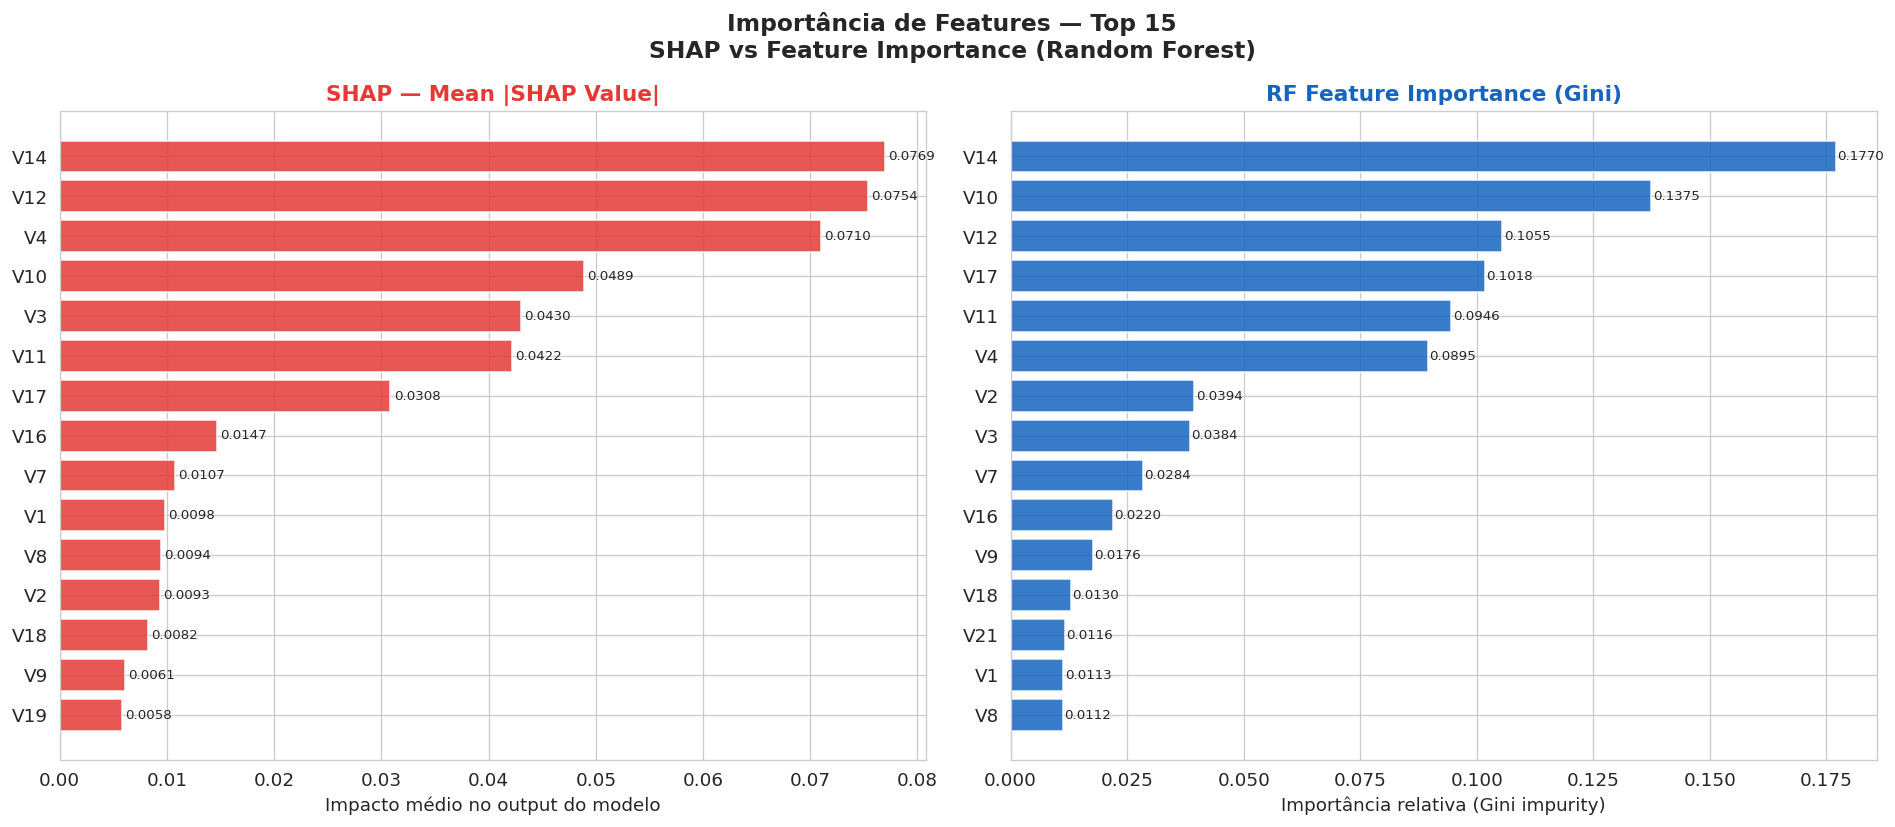


💡 SHAP é mais interpretável: mostra o impacto direcional de cada feature.
   RF Importance apenas diz 'quão útil' foi a feature nas divisões da árvore.


In [49]:
# ── SHAP vs RF Feature Importance ────────────────────────────────────────────
# Selecionar as SHAP values para a classe de fraude (índice 1) da última dimensão
# O shap_fraud possui a forma (amostras, features, classes), então pegamos a classe 1
shap_importance_values = shap_fraud[:, :, 1] if shap_fraud.ndim == 3 else shap_fraud

shap_imp = pd.DataFrame({
    "Feature":         X_test.columns,
    "SHAP Importance": np.abs(shap_importance_values).mean(axis=0)
}).sort_values("SHAP Importance", ascending=False)

rf_imp = pd.DataFrame({
    "Feature":       X_test.columns,
    "RF Importance": rf_model.feature_importances_
}).sort_values("RF Importance", ascending=False)

TOP = 15
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f"Importância de Features — Top {TOP}\nSHAP vs Feature Importance (Random Forest)",
             fontsize=14, fontweight='bold')

# SHAP
top_s = shap_imp.head(TOP)
axes[0].barh(range(TOP), top_s["SHAP Importance"].values[::-1], color="#E53935", alpha=0.85)
axes[0].set_yticks(range(TOP))
axes[0].set_yticklabels(top_s["Feature"].values[::-1])
axes[0].set_title("SHAP — Mean |SHAP Value|", color="#E53935")
axes[0].set_xlabel("Impacto médio no output do modelo")
for i, v in enumerate(top_s["SHAP Importance"].values[::-1]):
    axes[0].text(v + 0.0003, i, f"{v:.4f}", va='center', fontsize=8)

# RF Importance
top_r = rf_imp.head(TOP)
axes[1].barh(range(TOP), top_r["RF Importance"].values[::-1], color="#1565C0", alpha=0.85)
axes[1].set_yticks(range(TOP))
axes[1].set_yticklabels(top_r["Feature"].values[::-1])
axes[1].set_title("RF Feature Importance (Gini)", color="#1565C0")
axes[1].set_xlabel("Importância relativa (Gini impurity)")
for i, v in enumerate(top_r["RF Importance"].values[::-1]):
    axes[1].text(v + 0.0003, i, f"{v:.4f}", va='center', fontsize=8)

plt.tight_layout()
plt.savefig("09_feature_importance_comparativo.png", bbox_inches='tight')
plt.show()

print("\n💡 SHAP é mais interpretável: mostra o impacto direcional de cada feature.")
print("   RF Importance apenas diz 'quão útil' foi a feature nas divisões da árvore.")

---
## Resumo Final

In [48]:
# ── Resumo Final ─────────────────────────────────────────────────────────────
print("=" * 65)
print("          RESUMO DO DESAFIO — DETECÇÃO DE FRAUDES")
print("=" * 65)

print(f"\n{'DATASET'}")
print(f"  Total de transações : {len(df):>10,}")
print(f"  Transações normais  : {(df['Class']==0).sum():>10,}")
print(f"  Fraudes             : {(df['Class']==1).sum():>10,}")
print(f"  Taxa de fraude      : {df['Class'].mean()*100:>9.3f}%")

print(f"\n{'FEATURE ENGINEERING'}")
print("  hour_sin / hour_cos  — hora cíclica (seno/cosseno)")
print("  is_night             — indicador de transação noturna")
print("  log_amount           — log do valor (reduz skewness)")

print(f"\n{'TÉCNICAS DE BALANCEAMENTO'}")
print("  ✓ Undersampling (RandomUnderSampler)")
print("  ✓ Oversampling  (SMOTE)")

print(f"\n{'MODELOS AVALIADOS'}")
print("  ✓ Logistic Regression — Baseline")
print("  ✓ Logistic Regression — Undersampling")
print("  ✓ Logistic Regression — SMOTE")
print("  ✓ Random Forest — Pipeline + SMOTE")
print("  ✓ Random Forest — Random Forest otimizado (execução rápida)")

print(f"\n{'MÉTRICAS DO MELHOR MODELO (Random Forest)'}")
print(f"  Recall (Fraude)   : {recall_score(y_test, y_pred_best):.4f}")
print(f"  Precision (Fraude): {precision_score(y_test, y_pred_best):.4f}")
print(f"  F1-Score (Fraude) : {f1_score(y_test, y_pred_best):.4f}")
print(f"  ROC-AUC           : {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"  Avg Precision     : {average_precision_score(y_test, y_prob_best):.4f}")

print(f"\n{'EXPLICABILIDADE'}")
print("  ✓ SHAP TreeExplainer — importância global e local")
print("  ✓ Summary Bar Plot   — ranking de features")
print("  ✓ Beeswarm Plot      — direção e magnitude do impacto")
print("  ✓ Force Plot         — explicação individual de fraude")

print("\n" + "=" * 65)

          RESUMO DO DESAFIO — DETECÇÃO DE FRAUDES

DATASET
  Total de transações :    284,807
  Transações normais  :    284,315
  Fraudes             :        492
  Taxa de fraude      :     0.173%

FEATURE ENGINEERING
  hour_sin / hour_cos  — hora cíclica (seno/cosseno)
  is_night             — indicador de transação noturna
  log_amount           — log do valor (reduz skewness)

TÉCNICAS DE BALANCEAMENTO
  ✓ Undersampling (RandomUnderSampler)
  ✓ Oversampling  (SMOTE)

MODELOS AVALIADOS
  ✓ Logistic Regression — Baseline
  ✓ Logistic Regression — Undersampling
  ✓ Logistic Regression — SMOTE
  ✓ Random Forest — Pipeline + SMOTE
  ✓ Random Forest — Random Forest otimizado (execução rápida)

MÉTRICAS DO MELHOR MODELO (Random Forest)
  Recall (Fraude)   : 0.8571
  Precision (Fraude): 0.5385
  F1-Score (Fraude) : 0.6614
  ROC-AUC           : 0.9839
  Avg Precision     : 0.8267

EXPLICABILIDADE
  ✓ SHAP TreeExplainer — importância global e local
  ✓ Summary Bar Plot   — ranking de featur